# Chronological preprocessing and information boundaries

**Question.** Can every feature be reconstructed from strictly preceding permitted information?

The implementation below uses a global completion-time order and predicts an entire tied timestamp batch before updating state. Frozen early-window exposure factors and train-only target mappings are kept separate from learner feedback. Current completion-time predictors are excluded. Dependencies are the local raw inputs and the fixed protocol from Notebook 01.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
for area in ['Data','Models','Tables','Figures']:
    (ROOT/area/'Round2').mkdir(parents=True,exist_ok=True)
(ROOT/'Tables/Round2/manifests').mkdir(parents=True,exist_ok=True)
MODULE_NOTEBOOKS={'round2_analysis': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_data': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_models': ['03_baseline_models_and_error_diagnostics.ipynb', '05_proposed_model_development_and_ablations.ipynb'], 'revision_sensitivity': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_neural': '04_modern_models_and_comparative_diagnostics.ipynb', 'revision_evaluation': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_supplemental': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_provenance': '05_proposed_model_development_and_ablations.ipynb', 'revision_validation': '02_feature_analysis_and_leakage_safe_preprocessing.ipynb', 'revision_closure': '06_frozen_evaluation_statistics_and_publication_results.ipynb', 'revision_status': '06_frozen_evaluation_statistics_and_publication_results.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        names=MODULE_NOTEBOOKS[module.__name__]
        names=[names] if isinstance(names,str) else names
        cells=[]
        for name in names:
            notebook=nbformat.read(ROOT/'Notebooks'/name,4)
            cells.extend(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        cells.sort(key=lambda c:c.metadata.get('module_order',0))
        source=''.join(c.source.split('\n',1)[1] for c in cells)
        path=ROOT/'Notebooks'/names[-1]
        module.__file__=str(path)
        module.__notebook_source__=source
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+module.__name__,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line, source):
    """Load the visible definition cells as one module, without external Python files."""
    import importlib
    importlib.import_module(line.strip())

if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.text import Text
from IPython.display import HTML, Image, Markdown
from IPython.utils.capture import capture_output

font_path = font_manager.findfont("Times New Roman", fallback_to_default=False)
mpl.rcParams.update({
    "font.family": "Times New Roman", "font.size": 18,
    "axes.titlesize": 20, "axes.labelsize": 18,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 18, "figure.titlesize": 20,
    "figure.dpi": 350, "savefig.dpi": 350, "axes.unicode_minus": True,
})
pd.set_option("display.max_colwidth", None)

def show_table(frame, title, identifiers=(), width=5, rows=18):
    """Render every scientific row and column in compact, untruncated parts."""
    frame = frame.reset_index(drop=True)
    identifiers = [c for c in identifiers if c in frame]
    values = [c for c in frame if c not in identifiers]
    groups = [values[i:i + width] for i in range(0, len(values), width)] or [[]]
    display(Markdown("**" + title + "**"))
    for start in range(0, max(1, len(frame)), rows):
        for group in groups:
            part = frame.iloc[start:start + rows][identifiers + group]
            def number(x):
                if abs(x) < 5e-12: return "0"
                return f"{x:.3e}" if abs(x) < 1e-4 else f"{x:.6f}".rstrip("0").rstrip(".")
            display(HTML(part.to_html(index=False, border=0, na_rep="Not available",
                                      float_format=number, max_rows=None, max_cols=None)))

def save_canvas(fig, stem):
    """Save and inspect the exact PNG/PDF; display a single PNG below the cell."""
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text().strip():
            assert 18 <= text.get_fontsize() <= 20
            assert Path(font_manager.findfont(text.get_fontproperties(),
                                             fallback_to_default=False)).name == Path(font_path).name
    png = artifact_path("Figures") / (stem + ".png")
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=350)
    fig.savefig(pdf, dpi=350)
    plt.close(fig)
    display(Image(filename=str(png), width=1050))

def load_frozen_predictions():
    """Check recorded file hashes before reading all seed/window predictions."""
    paths = sorted(artifact_path("Data").glob("round2_predictions_seed*_fold*.parquet"))
    assert len(paths) == 60
    for path in paths:
        suffix = path.stem.removeprefix("round2_predictions_")
        manifest = json.loads((artifact_path("manifests") / ("round2_fit_" + suffix + ".json")).read_text())
        assert rd.digest(path) == manifest["prediction_hash"]
    return pd.concat([pd.read_parquet(path) for path in paths], ignore_index=True)


### Imports and constants

In [3]:
%%research_module revision_data
"""Versioned temporal data contract for the six technical-revision notebooks."""
from pathlib import Path
from collections import defaultdict, deque
from datetime import datetime, timezone
import ast
import hashlib
import json
import os
import platform
import sys
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.special import expit, logit
from sklearn.decomposition import TruncatedSVD

ROOT = Path(__file__).resolve().parent.parent
V = ROOT
RAW = ROOT / 'Data/Raw/Extracted/data'
KEYS = ['AnswerId', 'UserId', 'QuestionId']



### digest

In [4]:
%%research_module revision_data
def digest(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for block in iter(lambda: handle.read(8 << 20), b''):
            h.update(block)
    return h.hexdigest()



### object hash

In [5]:
%%research_module revision_data
def object_hash(obj):
    return hashlib.sha256(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()



### save json

In [6]:
%%research_module revision_data
def save_json(path, obj):
    Path(path).parent.mkdir(parents=True, exist_ok=True); Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2, default=str)+'\n')




### artifact path

In [7]:
%%research_module revision_data
def artifact_path(relative):
    p=Path(relative)
    if p.is_absolute():
        raise ValueError('Scientific artifacts must use project-relative paths')
    if p.parts[0]=='Notebooks':return ROOT/p
    if p.parts[0] in ['Data','Models','Tables','Figures']:
        return ROOT/p.parts[0]/'Round2'/Path(*p.parts[1:])
    return ROOT/'Tables/Round2/manifests'/p



### code digest

In [8]:
%%research_module revision_data
def code_digest(module_name):
    """Hash executable notebook source, excluding mutable display outputs."""
    import importlib
    return importlib.import_module(module_name).__notebook_source_sha256__



### source matches

In [9]:
%%research_module revision_data
def source_matches(module_name, recorded):
    return code_digest(module_name)==recorded



### artifact matches

In [10]:
%%research_module revision_data
def artifact_matches(relative, recorded):
    p=Path(relative)
    if p.suffix=='.py' and p.stem.startswith('revision_'):
        return source_matches(p.stem,recorded)
    return artifact_path(relative).is_file() and digest(artifact_path(relative))==recorded



### fit contract matches

In [11]:
%%research_module revision_data
def fit_contract_matches(saved,current):
    if any(saved[k]!=current[k] for k in ['seed','fold','start','end']):return False
    if not source_matches('revision_data',saved['data_helper_hash']):return False
    old=saved['input_code_helper_feature_split_hashes']
    new=current['input_code_helper_feature_split_hashes']
    canon=lambda key: str(artifact_path(key))
    old_canon={canon(k):(k,h) for k,h in old.items()}
    if set(old_canon)!=set(map(canon,new)):return False
    return all(artifact_matches(*old_canon[canon(key)]) and artifact_matches(key,h) for key,h in new.items())




### register

In [12]:
%%research_module revision_data
def register(path, stage, inputs=(), details=None):
    path = Path(path)
    record = {'artifact': str(path.relative_to(V)), 'sha256': digest(path),
              'stage': stage, 'created_utc': datetime.now(timezone.utc).isoformat(),
              'code_hash': code_digest(__name__),
              'inputs': {str(Path(p).relative_to(ROOT)): digest(p) for p in inputs},
              'details': details or {}}
    save_json(artifact_path('manifests')/f'{object_hash(record["artifact"])[:16]}.json', record)
    return record



### table

In [13]:
%%research_module revision_data
def table(name, frame, stage='data', inputs=()):
    path = artifact_path('Tables')/name
    frame.to_csv(path, index=False)
    register(path, stage, inputs)
    return frame



### hash users

In [14]:
%%research_module revision_data
def hash_users(values, salt):
    return np.array([int.from_bytes(hashlib.sha256(f'{salt}:{int(v)}'.encode()).digest()[:8], 'big') / 2**64 for v in values])



### population and protocol

In [15]:
%%research_module revision_data
def population_and_protocol():
    source = RAW/'train_data/train_task_1_2.csv'
    raw = pd.read_csv(source, usecols=KEYS+['IsCorrect'], dtype={k:'int32' for k in KEYS} | {'IsCorrect':'int8'})
    student = raw.groupby('UserId').size().rename('count').reset_index()
    question = raw.groupby('QuestionId').size().rename('count').reset_index()
    for name, frame in [('source_student_counts.parquet', student), ('source_question_counts.parquet', question)]:
        path=artifact_path('Data')/name; frame.to_parquet(path,index=False); register(path,'NB01',[source])
    rows=[]
    for label, frame in [('raw',raw),('eligible_ge20',raw[raw.UserId.isin(student.loc[student['count']>=20,'UserId'])])]:
        sc=frame.groupby('UserId').size(); qc=frame.groupby('QuestionId').size()
        rows.append(dict(population=label, interactions=len(frame), students=len(sc), questions=len(qc), prevalence=frame.IsCorrect.mean(), student_min=sc.min(), student_Q1=sc.quantile(.25), student_median=sc.median(), student_Q3=sc.quantile(.75), student_IQR=sc.quantile(.75)-sc.quantile(.25), question_median=qc.median(), question_fraction_le5=(qc<=5).mean(), question_fraction_le10=(qc<=10).mean(), question_fraction_le20=(qc<=20).mean(), unique_pairs=len(frame[['UserId','QuestionId']].drop_duplicates())))
    audit=table('source_population_audit.csv',pd.DataFrame(rows),'NB01',[source])
    availability={
        'QuestionId': {'status':'pre-response','basis':'Target question identity is required by the task.'},
        'UserId': {'status':'pre-response','basis':'Learner identity is required by the task.'},
        'subject_metadata': {'status':'pre-response-assumption','basis':'Static content hierarchy; no version-time provenance available.'},
        'DateAnswered': {'status':'post-response','basis':'Recorded answer completion timestamp; no separate presentation/prediction timestamp exists in supplied schemas.'},
        'AnswerId': {'status':'unknown','basis':'Alignment key only, never temporal tie ordering evidence.'},
        'IsCorrect': {'status':'post-response','basis':'Response outcome.'},
        'AnswerValue': {'status':'post-response','basis':'Chosen response.'},
        'Confidence': {'status':'post-response','basis':'Response-associated confidence.'},
        'GroupId_QuizId_SchemeOfWorkId': {'status':'unknown','basis':'Answer metadata; availability at prediction time not documented; excluded as current predictors.'},
        'demographics': {'status':'unknown','basis':'Snapshot effective dates unknown; subgroup descriptors only.'},
        'current_completion_time_features': {'status':'excluded','fields':['hour','day_of_week','month','age_at_answer','days_since_previous_interaction','days_since_previous_subject_interaction','session_position','new_session','inactivity_gap'],'basis':'No trustworthy prediction-time timestamp.'},
        'presentation_time_present':False,
        'interpretation':'Completion-ordered prequential diagnostic; concurrent presentations cannot be reconstructed.'}
    save_json(artifact_path('field_availability.json'),availability)
    stored_cohort={'salt':'revision_v2_primary','alternative_salts':[]}
    protocol={'namespace':'Round2','created_utc':datetime.now(timezone.utc).isoformat(),
        'plan_sha256':None,
        'preregistration':False,'confirmation':'Previously studied source; retrospective technical validation only.',
        'seeds':list(range(20260713,20260723)), 'outer_folds':6,'inner_folds':4,'bootstrap_B':5000,
        'cohort':{'algorithm':'sha256(UserId), eligibility at first observation','fraction':.025,'salt':stored_cohort['salt'],'alternative_salts':stored_cohort['alternative_salts'],'legacy_selection':'separate diagnostic'},
        'calendar':{'start':'2018-09-01','representation_end':'2018-12-01','initial_fit_end':'2019-06-01','initial_development_end':'2019-09-01','initial_calibration_end':'2019-11-01','outer_edges':['2019-11-01','2019-12-01','2020-01-01','2020-02-01','2020-03-01','2020-04-01','2020-04-30']},
        'calendar_rationale':'Whole-month cutoffs within observed 2018-09 to 2020-04 coverage, specified before revised model scores.',
        'feedback_modes':['learner_feedback','outcome_free','no_feedback'],
        'history_caps':[0,1,5,10,20,50], 'history_target_rule':'Same evaluation targets; earliest eligible target per user with at least 50 strictly prior events. Diagnostic population, not real novice cohort.',
        'ties':'Read all states before each completion-timestamp batch; update using symmetric sufficient statistics; AnswerId is alignment only.',
        'bkt_fixed':{'initial':.25,'slip':.10,'guess':.20,'learn':.08},
        'bkt_candidates':[{'initial':.25,'slip':.10,'guess':.20,'learn':.08},{'initial':.25,'slip':.15,'guess':.20,'learn':.05}],
        'ewm_alpha':.15,'elo_K':.08,
        'svd':{'components':8,'fit_period':'representation window only','sensitivity':['frozen_early','without_svd','legacy_retrospective_diagnostic']},
        'hgb':{'iterations':[80,100],'l2_candidates':[1.,2.], 'max_leaf_nodes':31,'min_samples_leaf':20,'early_stopping':False},
        'memory_candidates':[[2.,.35],[5.,.35],[5.,.50],[10.,.35],[20.,.35]],
        'fallback_candidates':[[50.,.15],[100.,.15],[200.,.15],[200.,.30],[500.,.15]],
        'calibration_candidates':['none','temperature','platt'],'selection_metric':'Log_Loss','main_metric':'ROC_AUC','main_contrast':'AdaptiveMath-AI minus HGB100',
        'main_bootstrap':'paired student multinomial','sensitivity_bootstrap':['question','crossed_pigeonhole'],
        'ece':{'primary_bins':15,'strategy':'equal_width','sensitivity_bins':[10,15],'extra_strategy':'equal_frequency'},
        'review_budgets':[.05,.10,.20,.30],'classification_threshold':.5,
        'neural':{'names':['DKT-inspired GRU proxy','SAKT-inspired attention proxy'],'seeds':[20260713,20260714,20260715],'history_length':30,'max_epochs':12,'patience':3,'learning_rates':[.001,.0003],'batch_size':512},
        'no_required_advantage':True,'no_fixed_legacy_N':True,'sensitivity_design':'One factor at a time; never Cartesian product.'}
    p=artifact_path('revision_protocol.json')
    if p.exists():
        old=json.loads(p.read_text()); protocol['created_utc']=old['created_utc']
        if old!=protocol: raise RuntimeError('Frozen protocol exists with different contents; explicit new version required.')
    else: save_json(p,protocol)
    save_json(artifact_path('confirmation_data_status.json'),{'status':'DATA_LIMITATION','reason':'No evidence of an untouched confirmation dataset or a never-used evaluation period. New splits of this source are not independent confirmation.'})
    table('development_decision_log.csv',pd.DataFrame([{'evidence':'legacy artifact manifests','available':True,'interpretation':'File hashes and modification times establish current snapshot, not original decision chronology.'},{'evidence':'revision_protocol.json','available':True,'interpretation':'Prospective specification of this revision; not retrospective preregistration of original study.'}]),'NB01')
    save_json(artifact_path('environment.json'),{'python':sys.version,'platform':platform.platform(),'cpu_count':os.cpu_count(),'numpy':np.__version__,'pandas':pd.__version__})
    save_json(artifact_path('execution_manifest.json'), {'status':'IN_PROGRESS','protocol':'Round2','raw_input':str(source.relative_to(ROOT)),'raw_sha256':digest(source),'external_plan_required':False})
    for name in ['revision_protocol.json','field_availability.json','confirmation_data_status.json','environment.json']:
        register(artifact_path(name),'NB01')
    return audit



### protocol

In [16]:
%%research_module revision_data
def protocol(): return json.loads((artifact_path('revision_protocol.json')).read_text())




### normalize id

In [17]:
%%research_module revision_data
def normalize_id(value):
    if value is None or pd.isna(value):return None
    try:
        v=float(str(value).strip().replace('−','-'))
        return int(v) if np.isfinite(v) and v>=0 and v.is_integer() else None
    except (TypeError,ValueError):return None



### is valid subject id

In [18]:
%%research_module revision_data
def is_valid_subject_id(value):return normalize_id(value) is not None



### is valid parent id

In [19]:
%%research_module revision_data
def is_valid_parent_id(value):return normalize_id(value) is not None



### raw prerequisites

In [20]:
%%research_module revision_data
def raw_prerequisites():
    names=['train_data/train_task_1_2.csv','metadata/answer_metadata_task_1_2.csv',
           'metadata/question_metadata_task_1_2.csv','metadata/subject_metadata.csv',
           'metadata/student_metadata_task_1_2.csv']
    rows=[]
    for name in names:
        p=RAW/name;exists=p.is_file()
        count=sum(len(c) for c in pd.read_csv(p,chunksize=1000000,usecols=[0])) if exists else 0
        rows.append({'file':str(p.relative_to(ROOT)),'found':exists,'rows_checked':count,
                     'sha256':digest(p) if exists else None,'status':'PASS' if exists and count else 'FAIL'})
    result=table('round2_raw_prerequisites.csv',pd.DataFrame(rows),'NB01')
    if not result.status.eq('PASS').all():raise FileNotFoundError('Required official Eedi inputs missing; see prerequisite table')
    return result



### dependency plan

In [21]:
%%research_module revision_data
def dependency_plan():
    entries=[('R1',1,'Six monthly windows; within-window primary estimator','No: old five-window predictions',True,'02/03/05/06'),
             ('R1',2,'Recency-matched QuestionId control','No: new requested control',True,'03/05/06'),
             ('R1',3,'Independent variant calibration','No: inherited calibrator invalid',True,'03/05/06'),
             ('R1',4,'Nullable hierarchy; no sentinel memory/state','Raw inputs only; derived chain invalid',True,'02/03/05/06'),
             ('R1',6,'Raw-only clean execution and matched outputs','No: clean run must generate outputs',True,'01–06'),
             ('R2',1,'Full primary hash-cohort question frequencies','Raw cohort IDs reusable after identity check',False,'06')]
    return table('round2_dependency_plan.csv',pd.DataFrame(entries,columns=['Reviewer','Comment','Required work','Existing artifact usable?','Refit required?','Target notebook']),'NB01')



### Join response events and nullable hierarchy

In [22]:
%%research_module revision_data
def load_events():
    """Select learners by identifier before reading labels or activity lengths."""
    pr=protocol(); source=RAW/'train_data/train_task_1_2.csv'
    counts=pd.read_parquet(artifact_path('Data/source_student_counts.parquet'))
    salts=[pr['cohort']['salt']]+pr['cohort']['alternative_salts']
    users={salt:set(counts.loc[hash_users(counts.UserId,salt)<pr['cohort']['fraction'],'UserId']) for salt in salts}
    union=set().union(*users.values()); parts=[]
    for chunk in pd.read_csv(source,chunksize=1_000_000): parts.append(chunk[chunk.UserId.isin(union)])
    events=pd.concat(parts,ignore_index=True); answers=set(events.AnswerId); parts=[]
    for chunk in pd.read_csv(RAW/'metadata/answer_metadata_task_1_2.csv',chunksize=1_000_000,low_memory=False):
        parts.append(chunk[chunk.AnswerId.isin(answers)])
    meta=pd.concat(parts,ignore_index=True)
    assert meta.AnswerId.is_unique
    events=events.merge(meta,on='AnswerId',validate='one_to_one')
    events['DateAnswered']=pd.to_datetime(events.DateAnswered,utc=True,errors='coerce')
    if events.DateAnswered.isna().any(): raise ValueError('Missing event timestamps require explicit data protocol.')
    subjects=pd.read_csv(RAW/'metadata/subject_metadata.csv'); subjects=subjects.dropna(subset=['SubjectId'])
    valid_subjects=subjects.SubjectId.map(is_valid_subject_id)
    subjects=subjects.loc[valid_subjects].copy()
    levels=dict(zip(subjects.SubjectId.astype(int),subjects.Level))
    parents={int(r.SubjectId):normalize_id(r.ParentId) for r in subjects.itertuples()}
    questions=pd.read_csv(RAW/'metadata/question_metadata_task_1_2.csv')
    def primary(text):
        try: ids=ast.literal_eval(text) if isinstance(text,str) else []
        except (ValueError,SyntaxError): ids=[]
        valid=[normalize_id(x) for x in ids if is_valid_subject_id(x) and normalize_id(x) in levels]
        return max(valid,key=lambda x:(levels.get(x,-1),x)) if valid else pd.NA
    questions['primary_subject_id']=pd.array(questions.SubjectId.map(primary),dtype='Int64')
    questions['parent_subject_id']=pd.array(questions.primary_subject_id.map(lambda x: parents.get(normalize_id(x),pd.NA)),dtype='Int64')
    questions.loc[~questions.primary_subject_id.map(is_valid_subject_id),'parent_subject_id']=pd.NA
    questions['subject_depth']=questions.primary_subject_id.map(levels).astype('float64')
    events=events.merge(questions[['QuestionId','primary_subject_id','parent_subject_id','subject_depth']],on='QuestionId',how='left',validate='many_to_one')
    students=pd.read_csv(RAW/'metadata/student_metadata_task_1_2.csv')
    events=events.merge(students[['UserId','Gender','PremiumPupil']],on='UserId',how='left',validate='many_to_one')
    events=events.sort_values(['DateAnswered','AnswerId']).reset_index(drop=True)
    manifest=[]
    for salt,selected in users.items():
        d=events[events.UserId.isin(selected)].copy()
        path=artifact_path('Data')/f'events_{salt}.parquet';d.to_parquet(path,index=False);register(path,'NB02',[source,artifact_path('revision_protocol.json')])
        manifest.append({'cohort':salt,'N':len(d),'students':d.UserId.nunique(),'questions':d.QuestionId.nunique(),'rule':'legacy full-activity diagnostic' if salt=='legacy_selection' else 'sha256 identifier inclusion at first observation; p=0.025'})
    table('cohort_sensitivity_manifest.csv',pd.DataFrame(manifest),'NB02')
    save_json(artifact_path('state_update_contract.json'),{'before':'Emit every feature for a timestamp batch before any updates from that batch.', 'global_and_item':'Prefix fit labels only; no evaluation label updates.', 'learner_feedback':'Known completed responses update learner and concept states after the timestamp batch.', 'outcome_free':'Exposure/collaborative counts update after batch; label-dependent states freeze after fitting period.', 'no_feedback':'No learner/exposure/session state updates after fitting period.', 'ties':'Symmetric batch: summed Elo increments at prebatch predictions, EWM decay^n with batch mean, BKT batch likelihood and symmetric n-opportunity transition.', 'ewm':'E0=0.5; singleton E=0.15*y+0.85*E','sessions':'No current-session predictors without presentation timestamps; no implicit session updates.','collaborative':'Average frozen early item vectors for permitted known-question exposures.', 'primary_subject_rule':'Maximum depth, then maximum SubjectId.'})
    return pd.DataFrame(manifest)



### Fit and freeze the early-window exposure representation

In [23]:
%%research_module revision_data
def fit_representation(events, end):
    early=events[events.DateAnswered<pd.Timestamp(end,tz='UTC')]
    users=np.sort(early.UserId.unique()); questions=np.sort(early.QuestionId.unique())
    uc=pd.Categorical(early.UserId,categories=users).codes; qc=pd.Categorical(early.QuestionId,categories=questions).codes
    matrix=sparse.csr_matrix((np.ones(len(early)),(uc,qc)),shape=(len(users),len(questions))); matrix.data[:]=1
    rank=min(8,min(matrix.shape)-1)
    if rank<1: raise ValueError('Insufficient early exposure matrix')
    svd=TruncatedSVD(n_components=rank,n_iter=7,random_state=20260713);svd.fit(matrix)
    factors={int(q):v for q,v in zip(questions,svd.components_.T)}
    return factors,early

FEATURES=['prior_interaction_count','prior_correct_count','prior_cumulative_accuracy','rolling_accuracy_5','rolling_accuracy_20','rolling_accuracy_50','ewm_accuracy','prior_subject_opportunities','prior_subject_accuracy','bkt_mastery','elo_student_ability','elo_probability','question_historical_accuracy','question_difficulty','question_popularity_past','rasch_ability','rasch_question_difficulty','subject_historical_accuracy','student_question_similarity','matrix_factorization_score','collaborative_state_norm','subject_depth']



### Chronological event replay

In [24]:
%%research_module revision_data
class EventReplay:
    """No current outcome or completion timestamp enters a prediction vector."""
    def __init__(self, factors=None, cap=None, feedback='learner_feedback', item_fit_end=None, ewm_first=False, bkt=None, feedback_start=None):
        self.factors=factors or {};self.cap=cap;self.feedback=feedback;self.item_fit_end=pd.Timestamp(item_fit_end,tz='UTC') if isinstance(item_fit_end,str) else item_fit_end
        self.ewm_first=ewm_first;self.bkt=bkt or {'initial':.25,'slip':.10,'guess':.20,'learn':.08}
        self.feedback_start=pd.Timestamp(feedback_start,tz='UTC') if isinstance(feedback_start,str) else (feedback_start if feedback_start is not None else self.item_fit_end)
        self.hist=defaultdict(list);self.items=defaultdict(lambda:[0.,0.,0.]);self.subjects=defaultdict(lambda:[0.,0.]);self.total=[0.,0.];self._cache={}
    def learner(self,u):
        batches=self.hist[u]
        if self.cap is not None:
            # A cap cannot choose an undocumented ordering inside a tied batch.
            chosen=[];n=0
            for batch in reversed(batches):
                if n+len(batch)>self.cap: break
                chosen.append(batch);n+=len(batch)
            batches=list(reversed(chosen))
        consumed=0
        if self.cap is None and u in self._cache:
            consumed,n,correct,ewm,elo,sub,master,recent,vector_sum,vector_n=self._cache[u]
            batches=batches[consumed:]
        else:
            n=correct=0.;ewm=.5;elo=0.;sub=defaultdict(lambda:[0.,0.]);master=defaultdict(lambda:self.bkt['initial']);recent=deque(maxlen=50);vector_sum=None;vector_n=0
        for batch in batches:
            labelled=[r for r in batch if r['label_allowed']]
            if labelled:
                ys=np.array([r['y'] for r in labelled]);k=len(ys)
                ewm=float(ys.mean()) if self.ewm_first and n==0 else .85**k*ewm+(1-.85**k)*ys.mean()
                elo+=.08*sum(r['y']-expit(elo-r['item_rating']) for r in labelled)
                for s in set(r['s'] for r in labelled if is_valid_subject_id(r['s'])):
                    yy=[r['y'] for r in labelled if r['s']==s];a=sum(yy);b=len(yy)-a;bp=self.bkt;p=master[s]
                    odds=logit(np.clip(p,1e-8,1-1e-8))+a*np.log((1-bp['slip'])/bp['guess'])+b*np.log(bp['slip']/(1-bp['guess']))
                    post=expit(odds);master[s]=1-(1-post)*(1-bp['learn'])**len(yy)
                    sub[s][0]+=len(yy);sub[s][1]+=a
                recent.append((k,float(ys.sum())));n+=k;correct+=ys.sum()
            for row in batch:
                if row['q'] in self.factors:
                    vector_sum=self.factors[row['q']].copy() if vector_sum is None else vector_sum+self.factors[row['q']]
                    vector_n+=1
        if self.cap is None:
            self._cache[u]=(len(self.hist[u]),n,correct,ewm,elo,sub,master,recent,vector_sum,vector_n)
        rolling=[]
        for w in [5,20,50]:
            used=total=0.
            for k,s in reversed(recent):
                if used+k>w: break
                used+=k;total+=s
            rolling.append(total/used if used else .5)
        vec=vector_sum/vector_n if vector_n else None
        return n,correct,ewm,elo,sub,master,rolling,vec
    def emit_batch(self,batch):
        output=[];cache={}
        prior=(self.total[1]+1)/(self.total[0]+2)
        for r in batch:
            u,q,s=int(r.UserId),int(r.QuestionId),normalize_id(r.primary_subject_id)
            if u not in cache: cache[u]=self.learner(u)
            n,c,e,a,sub,bkt,rolling,vec=cache[u];qn,qc,b=self.items[q];sn,sc=self.subjects.get(s,[0.,0.]) if s is not None else [0.,0.]
            qacc=(qc+20*prior)/(qn+20);qs=(sc+20*prior)/(sn+20)
            qv=self.factors.get(q);cos=0.
            if qv is not None and vec is not None:
                den=np.linalg.norm(qv)*np.linalg.norm(vec);cos=float(vec@qv/den) if den else 0.
            vn=float(np.linalg.norm(vec)) if vec is not None else 0.;un,uc=sub.get(s,[0.,0.]) if s is not None else [0.,0.]
            output.append([n,c,c/n if n else .5,*rolling,e,un,uc/un if un else .5,bkt.get(s,self.bkt['initial']),a,expit(a-b),qacc,1-qacc,qn,logit((c+2)/(n+4)),-logit(np.clip(qacc,1e-6,1-1e-6)),qs if s is not None else np.nan,cos,expit(3*cos),vn,float(r.subject_depth) if pd.notna(r.subject_depth) else np.nan])
        return np.asarray(output,float)
    def update_batch(self,batch, timestamp):
        fit=self.item_fit_end is None or timestamp<self.item_fit_end
        allow_training_feedback=self.feedback_start is None or timestamp<self.feedback_start
        if not allow_training_feedback and self.feedback=='no_feedback': return
        by_user=defaultdict(list);item_delta=defaultdict(float)
        for r in batch:
            u,q,s=int(r.UserId),int(r.QuestionId),normalize_id(r.primary_subject_id)
            label_allowed=allow_training_feedback or self.feedback=='learner_feedback';rating=self.items[q][2]
            by_user[u].append({'q':q,'s':s,'y':int(r.IsCorrect),'label_allowed':label_allowed,'item_rating':rating,'AnswerId':int(r.AnswerId)})
            if fit:
                ability=self.learner(u)[3];item_delta[q]-=.08*(r.IsCorrect-expit(ability-rating))
        for u,rows in by_user.items(): self.hist[u].append(rows)
        if fit:
            for r in batch:
                q,s=int(r.QuestionId),normalize_id(r.primary_subject_id)
                self.items[q][0]+=1;self.items[q][1]+=r.IsCorrect;self.total[0]+=1;self.total[1]+=r.IsCorrect
                if s is not None:self.subjects[s][0]+=1;self.subjects[s][1]+=r.IsCorrect
            for q,delta in item_delta.items(): self.items[q][2]+=delta
    def run(self,events):
        rows=[];ids=[]
        for stamp,g in events.sort_values('DateAnswered',kind='stable').groupby('DateAnswered',sort=False):
            batch=list(g.itertuples(index=False));rows.append(self.emit_batch(batch));ids.extend(g.AnswerId)
            self.update_batch(batch,stamp)
        return pd.DataFrame(np.concatenate(rows),columns=FEATURES,index=pd.Index(ids,name='AnswerId')) if rows else pd.DataFrame(columns=FEATURES)



### replay tests

In [25]:
%%research_module revision_data
def replay_tests():
    from pandas.testing import assert_frame_equal
    t=pd.DataFrame({'AnswerId':range(1,7),'UserId':[1,1,2,1,2,1],'QuestionId':[1,2,1,1,2,2],'IsCorrect':[1,0,1,1,0,1],'primary_subject_id':[1]*6,'subject_depth':[1]*6,'DateAnswered':pd.to_datetime(['2018-09-01','2018-09-02','2018-09-02','2018-09-03','2018-09-04','2018-09-05'],utc=True)})
    rows=[]
    def passed(name): rows.append({'test':name,'status':'PASS','data':'synthetic_unit_test_only'})
    baseline=EventReplay().run(t)
    changed=t.copy();changed.loc[changed.AnswerId>=4,'IsCorrect']=1-changed.loc[changed.AnswerId>=4,'IsCorrect']
    assert_frame_equal(baseline.loc[:4],EventReplay().run(changed).loc[:4]);passed('current_and_future_label_invariance')
    assert_frame_equal(baseline.sort_index(),EventReplay().run(t.sample(frac=1,random_state=2)).sort_index());passed('tie_permutation_invariance')
    nf=EventReplay(feedback='no_feedback',item_fit_end='2018-09-03').run(t)
    assert nf.loc[4,'prior_interaction_count']==nf.loc[6,'prior_interaction_count'];passed('no_feedback_state_frozen')
    zero=EventReplay(cap=0).run(t);assert (zero.prior_interaction_count==0).all() and (zero.ewm_accuracy==.5).all() and (zero.elo_student_ability==0).all();passed('cap_zero_all_learner_state')
    assert np.isclose(baseline.loc[2,'ewm_accuracy'],.575);passed('EWM_prior_point5')
    f1,_=fit_representation(t,'2018-09-03'); f2,_=fit_representation(pd.concat([t,changed.assign(AnswerId=lambda d:d.AnswerId+10,DateAnswered=pd.Timestamp('2021-01-01',tz='UTC'))]),'2018-09-03')
    assert all(np.array_equal(f1[k],f2[k]) for k in f1);passed('future_exposure_cannot_change_frozen_SVD')
    assert np.isfinite(EventReplay().emit_batch(list(t.iloc[:1].itertuples(index=False)))).all();passed('empty_history_and_factor_fallback')
    return table('replay_unit_tests.csv',pd.DataFrame(rows),'NB02')



### Construct permitted features

In [26]:
%%research_module revision_data
def build_features():
    tests=pd.read_csv(artifact_path('Tables/replay_unit_tests.csv')); assert tests.status.eq('PASS').all()
    pr=protocol();salt=pr['cohort']['salt'];events=pd.read_parquet(artifact_path('Data')/f'events_{salt}.parquet')
    factors,early=fit_representation(events,pr['calendar']['representation_end'])
    # Representation features on the representation-fitting rows are not supervised inputs.
    cutoff=pr['calendar']['representation_end'];state=EventReplay(factors=factors,item_fit_end=cutoff)
    features=state.run(events);frame=events.merge(features.reset_index(),on='AnswerId',validate='one_to_one',suffixes=('_metadata',''))
    frame['split']=np.select([frame.DateAnswered<pd.Timestamp(cutoff,tz='UTC'),frame.DateAnswered<pd.Timestamp(pr['calendar']['initial_fit_end'],tz='UTC'),frame.DateAnswered<pd.Timestamp(pr['calendar']['initial_development_end'],tz='UTC'),frame.DateAnswered<pd.Timestamp(pr['calendar']['initial_calibration_end'],tz='UTC')],['representation','fit','development','calibration'],default='evaluation')
    path=artifact_path('Data/features_primary.parquet');frame.to_parquet(path,index=False)
    register(path,'NB02',[artifact_path('Data')/f'events_{salt}.parquet',artifact_path('revision_protocol.json')],{'feature_names':FEATURES,'representation_rows_excluded_from_supervised_fit':True})
    manifest=frame[KEYS+['DateAnswered','split']].copy();manifest['outer_fold']=-1
    edges=pd.to_datetime(pr['calendar']['outer_edges'],utc=True)
    for fold,(left,right) in enumerate(zip(edges[:-1],edges[1:])): manifest.loc[(manifest.DateAnswered>=left)&(manifest.DateAnswered<right),'outer_fold']=fold
    manifest.to_parquet(artifact_path('Data/split_manifest.parquet'),index=False)
    table('split_date_overlap.csv',frame.groupby('split').DateAnswered.agg(['min','max','size']).reset_index(),'NB02')
    sizes=events.groupby('DateAnswered').size();table('timestamp_tie_audit.csv',pd.DataFrame([{'scope':'all_events','groups':len(sizes),'tied_groups':int((sizes>1).sum()),'tied_events':int(sizes[sizes>1].sum()),'max_group':sizes.max(),'within_user_ties':int(events.duplicated(['UserId','DateAnswered'],keep=False).sum()),'within_question_ties':int(events.duplicated(['QuestionId','DateAnswered'],keep=False).sum())}]),'NB02')
    early[KEYS+['DateAnswered']].to_parquet(artifact_path('Data/representation_fit_ids.parquet'),index=False)
    save_json(artifact_path('svd_window_manifest.json'),{'fit_end_exclusive':cutoff,'fit_rows':len(early),'row_ids_hash':digest(artifact_path('Data/representation_fit_ids.parquet')),'transform_on_supervised_rows':'Frozen strictly earlier exposure factors; learner vector updates only after permitted exposures.'})
    save_json(artifact_path('feature_contract.json'),{'features':FEATURES,'feature_hash':object_hash(FEATURES),'helper_hash':code_digest(__name__),'input_hash':digest(artifact_path('Data')/f'events_{salt}.parquet'),'split_hash':digest(artifact_path('Data/split_manifest.parquet')),'protocol_hash':digest(artifact_path('revision_protocol.json'))})
    mapping=early[KEYS+['DateAnswered']].copy();mapping['role']='prefix_mapping_and_global_prior_and_item_Elo_fit';mapping.to_parquet(artifact_path('Data/mapping_provenance.parquet'),index=False)
    table('feature_source_time_audit.csv',pd.DataFrame([{'feature':name,'fit_source_end_exclusive':cutoff,'supervised_start_inclusive':cutoff,'history_rule':'strictly earlier timestamp batch','uses_current_completion_time':False} for name in FEATURES]),'NB02')
    frame.loc[frame.split.ne('representation'),KEYS+FEATURES].head(30).to_parquet(artifact_path('Data/state_trace_examples.parquet'),index=False)
    return frame.groupby('split').agg(N=('AnswerId','size'),students=('UserId','nunique'),questions=('QuestionId','nunique'),prevalence=('IsCorrect','mean')).reset_index()

### Imports and constants

In [27]:
%%research_module revision_sensitivity
"""One-factor sensitivity and train-only psychometric checks."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import copy
import json
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit,logit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from numba import njit
from revision_data import ROOT,V,KEYS,FEATURES,EventReplay,fit_representation,protocol,table,save_json,register,digest
from revision_models import metrics,safe_p,prediction_frame,predict,calibrate,hierarchy_apply



### bkt training loss

In [28]:
%%research_module revision_sensitivity
@njit
def bkt_training_loss(theta, batches, boundaries):
    initial,slip,guess,learn=theta;loss=0.
    for group in range(len(boundaries)-1):
        p=initial
        for i in range(boundaries[group],boundaries[group+1]):
            correct,n=batches[i];pred=min(max(p*(1-slip)+(1-p)*guess,1e-8),1-1e-8)
            loss-=correct*np.log(pred)+(n-correct)*np.log1p(-pred)
            prior=min(max(p,1e-8),1-1e-8)
            odds=np.log(prior/(1-prior))+correct*np.log((1-slip)/guess)+(n-correct)*np.log(slip/(1-guess))
            posterior=1/(1+np.exp(-min(max(odds,-700),700)))
            p=1-(1-posterior)*(1-learn)**n
    return loss



### data sensitivities

In [29]:
%%research_module revision_sensitivity
def data_sensitivities():
    pr=protocol();base=pd.read_parquet(artifact_path('Data/features_primary.parquet'));events=pd.read_parquet(artifact_path('Data')/f'events_{pr["cohort"]["salt"]}.parquet');end=pr['calendar']['representation_end'];start=pr['calendar']['initial_calibration_end']
    factors,early=fit_representation(events,end)
    outputs=[]
    for mode in ['outcome_free','no_feedback']:
        state=EventReplay(factors=factors,item_fit_end=end,feedback=mode,feedback_start=start)
        f=state.run(events);frame=events.merge(f.reset_index(),on='AnswerId',suffixes=('_metadata',''))
        path=artifact_path('Data')/f'features_{mode}.parquet';frame.to_parquet(path,index=False);register(path,'NB02',[artifact_path('revision_protocol.json'),artifact_path('Data/features_primary.parquet')])
        outputs.append({'scenario':mode,'N':len(frame),'targets':'same AnswerId as primary','state_updates_after':start})
    save_json(artifact_path('feedback_scenario_manifest.json'),outputs)
    # Fixed targets are selected using past history only, before revised model scores.
    targets=base[(base.split=='evaluation')&(base.prior_interaction_count>=50)].sort_values(['DateAnswered','AnswerId']).groupby('UserId').head(1)
    targets[KEYS+['DateAnswered','prior_interaction_count']].to_parquet(artifact_path('Data/fixed_target_history_manifest.parquet'),index=False)
    target_ids=set(targets.AnswerId);state=EventReplay(factors=factors,item_fit_end=end);rows={h:[] for h in pr['history_caps']}
    for stamp,g in events.groupby('DateAnswered',sort=False):
        chosen=g[g.AnswerId.isin(target_ids)];batch=list(g.itertuples(index=False))
        if len(chosen):
            for h in rows:
                state.cap=h;f=state.emit_batch(list(chosen.itertuples(index=False)));out=chosen.copy()
                for j,name in enumerate(FEATURES): out[name]=f[:,j]
                out['history_cap']=h;rows[h].append(out)
            state.cap=None
        state.update_batch(batch,stamp)
    for h,parts in rows.items():
        frame=pd.concat(parts,ignore_index=True);assert set(frame.AnswerId)==target_ids
        frame.to_parquet(artifact_path('Data')/f'history_cap_features_{h}.parquet',index=False)
    # Alternate EWM has precisely the same predictors except its defined initialization.
    alt=EventReplay(factors=factors,item_fit_end=end,ewm_first=True).run(events)
    ewm=base[['AnswerId','ewm_accuracy']].merge(alt[['ewm_accuracy']].rename(columns={'ewm_accuracy':'first_y_EWM'}).reset_index(),on='AnswerId')
    ewm['absolute_change']=(ewm.ewm_accuracy-ewm.first_y_EWM).abs()
    table('ewm_sensitivity.csv',ewm[['absolute_change']].describe(percentiles=[.5,.9,.99]).reset_index(),'NB02')
    ewm.to_parquet(artifact_path('Data/ewm_sensitivity_rows.parquet'),index=False)
    # Align to legacy on stable answer keys, never positional interaction IDs.
    old=pd.read_parquet(ROOT/'Data/Unified/modeling_dataset.parquet',columns=['answer_id','elo_probability','elo_student_ability']).rename(columns={'answer_id':'AnswerId','elo_probability':'legacy_elo_probability','elo_student_ability':'legacy_elo_student_ability'})
    joined=base[['AnswerId','elo_probability','elo_student_ability']].merge(old,on='AnswerId');delta=abs(joined.elo_probability-joined.legacy_elo_probability)
    table('elo_correction_delta.csv',pd.DataFrame([{'matched_AnswerId':len(joined),'changed':int((delta>1e-8).sum()),'changed_fraction':float((delta>1e-8).mean()),'mean_abs_delta':delta.mean(),'p50_abs_delta':delta.quantile(.5),'p95_abs_delta':delta.quantile(.95),'max_abs_delta':delta.max(),'interpretation':'Corrected temporal replay plus conservative mapping changes; predictor delta only, model metric delta requires refitting.'}]),'NB02')
    joined.to_parquet(artifact_path('Data/elo_matched_rows.parquet'),index=False)
    early_end=pd.Timestamp(start,tz='UTC');fit=base[base.DateAnswered<early_end]
    slices=base[base.split.eq('evaluation')][KEYS+['DateAnswered','prior_interaction_count']].copy();slices['first_response']=slices.prior_interaction_count.eq(0);slices['first_5']=slices.prior_interaction_count.lt(5);slices['known_training_question']=slices.QuestionId.isin(fit.QuestionId);slices['known_training_student']=slices.UserId.isin(fit.UserId)
    slices.to_parquet(artifact_path('Data/cold_start_slice_manifest.parquet'),index=False)
    save_json(artifact_path('availability_ablation_manifest.json'),{'primary':'conservative no current completion-time predictors','excluded':['hour','day','month','age_at_answer','current gaps','current session'],'legacy':'retrospective diagnostic only; availability unknown','uncertainty':'Actual presentation times and overlapping presentations unavailable.'})
    return pd.DataFrame(outputs+ [{'scenario':f'history_cap_{h}','N':len(targets),'targets':'fixed AnswerId, whole tie batches, realized history <= requested cap','state_updates_after':start} for h in rows])



### psychometric checks

In [30]:
%%research_module revision_sensitivity
def psychometric_checks():
    pr=protocol();d=pd.read_parquet(artifact_path('Data/features_primary.parquet'))
    fit=d[d.DateAnswered<pd.Timestamp(pr['calendar']['initial_fit_end'],tz='UTC')];test=d[d.split.eq('evaluation')]
    enc=OneHotEncoder(handle_unknown='ignore',dtype=np.float64)
    x=enc.fit_transform(fit[['UserId','QuestionId']]);model=LogisticRegression(C=1.,solver='lbfgs',max_iter=300,tol=1e-7)
    model.fit(x,fit.IsCorrect);p=model.predict_proba(enc.transform(test[['UserId','QuestionId']]))[:,1]
    rows=[{'model':'Joint_ridge_logistic_student_item_intercepts','fit_rows':len(fit),'fit_max_time':str(fit.DateAnswered.max()),'iterations':int(model.n_iter_[0]),'converged':model.n_iter_[0]<300,'identifiability':'L2 penalty identifies student/item contributions; unknown one-hot blocks zero, learned global intercept retained.',**metrics(test.IsCorrect,p)}]
    # Fit BKT on chronological training batches only. No evaluation labels enter objective.
    groups=[]
    for _,g in fit.groupby(['UserId','primary_subject_id']):
        batches=g.groupby('DateAnswered').IsCorrect.agg(['sum','size']);groups.append(batches[['sum','size']].to_numpy())
    batches=np.concatenate(groups).astype(float);boundaries=np.r_[0,np.cumsum([len(g) for g in groups])]
    def objective(theta): return bkt_training_loss(theta,batches,boundaries)
    init=np.array([.25,.10,.20,.08]);result=minimize(objective,init,method='L-BFGS-B',bounds=[(.01,.99),(.01,.45),(.01,.45),(.001,.4)],options={'maxiter':50,'ftol':1e-8})
    fitted=dict(zip(['initial','slip','guess','learn'],result.x))
    save_json(artifact_path('Models/bkt_rasch_fitting.json'),{'BKT':{'parameters':fitted,'objective':float(result.fun),'converged':bool(result.success),'iterations':int(result.nit),'message':str(result.message)},'fit_end_exclusive':pr['calendar']['initial_fit_end'],'fit_ids_hash':digest(artifact_path('Data/features_primary.parquet')),'Rasch':{'iterations':int(model.n_iter_[0]),'regularization_C':1.,'objective':'Penalized binary log loss with student and item intercepts.'}})
    fit[KEYS+['DateAnswered']].to_parquet(artifact_path('Data/psychometric_fit_ids.parquet'),index=False)
    for label,params in [('BKT_fixed',pr['bkt_fixed']),('BKT_train_fitted',fitted),('BKT_prespecified_sensitivity',pr['bkt_candidates'][1])]:
        values=EventReplay(item_fit_end=pr['calendar']['initial_fit_end'],bkt=params).run(d)
        mastery=values.loc[test.AnswerId,'bkt_mastery'].to_numpy();prob=mastery*(1-params['slip'])+(1-mastery)*params['guess']
        rows.append({'model':label,'fit_rows':len(fit),'converged':bool(result.success) if label=='BKT_train_fitted' else None,**metrics(test.IsCorrect,prob)})
        out=test[KEYS+['IsCorrect']].copy();out['p']=prob;out['model']=label;out.to_parquet(artifact_path('Data')/f'{label}_predictions.parquet',index=False)
    return table('psychometric_train_only_checks.csv',pd.DataFrame(rows),'NB03')

### Imports and constants

In [31]:
%%research_module revision_validation
"""Additional invariant and real-data smoke checks; no model-score gates."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import numpy as np
import pandas as pd
from pandas.testing import assert_frame_equal
from revision_data import V,FEATURES,EventReplay,protocol,table,digest



### verify replay and inputs

In [32]:
%%research_module revision_validation
def verify_replay_and_inputs():
    records=[]
    d=pd.DataFrame({'AnswerId':[1,2,3,4,5],'UserId':[1,1,1,1,1],'QuestionId':[1,1,2,1,2],'IsCorrect':[1,0,1,1,0],'primary_subject_id':[2]*5,'subject_depth':[3]*5,'DateAnswered':pd.to_datetime(['2018-09-01','2018-09-02','2018-09-02','2018-09-03','2018-09-04'],utc=True)})
    kwargs={'factors':{1:np.array([1.,0.]),2:np.array([0.,1.])},'item_fit_end':'2018-09-02'}
    f=EventReplay(**kwargs).run(d);g=EventReplay(**kwargs).run(d.iloc[[0,2,1,3,4]])
    assert_frame_equal(f.sort_index(),g.sort_index(),rtol=1e-10,atol=1e-10)
    assert f.loc[2,'prior_interaction_count']==f.loc[3,'prior_interaction_count']==1
    assert np.isclose(f.loc[2,'bkt_mastery'],.632)
    records.append({'test':'same_learner_tie_batch_and_BKT_reference','status':'PASS'})
    free=EventReplay(**kwargs,feedback='outcome_free').run(d);none=EventReplay(**kwargs,feedback='no_feedback').run(d)
    for col in ['prior_correct_count','ewm_accuracy','bkt_mastery','elo_student_ability']:
        np.testing.assert_allclose(free.loc[2:,col],free.loc[2,col]);np.testing.assert_allclose(none.loc[2:,col],none.loc[2,col])
    assert free.loc[4,'collaborative_state_norm']!=none.loc[4,'collaborative_state_norm']
    records.append({'test':'outcome_free_exposures_without_label_updates','status':'PASS'})
    forbidden={'hour','month','day_of_week','age_at_answer','new_session','session_id','session_position','days_since_previous_interaction','days_since_previous_subject_interaction','inactivity_gap','DateAnswered','IsCorrect','Confidence','AnswerValue'}
    assert forbidden.isdisjoint(FEATURES);records.append({'test':'conservative_feature_set','status':'PASS'})
    import json
    contract=json.loads((artifact_path('feature_contract.json')).read_text());assert source_matches('revision_data',contract['helper_hash']);records.append({'test':'feature_helper_hash_matches_executed_contract','status':'PASS'})
    path=artifact_path('Data')/f'events_{protocol()["cohort"]["salt"]}.parquet';real=pd.read_parquet(path).head(512).copy()
    one=EventReplay().run(real);mutated=real.copy();stamp=real.DateAnswered.sort_values().iloc[len(real)//2];mutated.loc[mutated.DateAnswered>=stamp,'IsCorrect']=1-mutated.loc[mutated.DateAnswered>=stamp,'IsCorrect'];two=EventReplay().run(mutated)
    ids=real.loc[real.DateAnswered<=stamp,'AnswerId'];assert_frame_equal(one.loc[ids],two.loc[ids]);assert np.isfinite(one.to_numpy()).all();records.append({'test':'real_data_smoke_future_label_invariance','status':'PASS'})
    ids=None
    for cap in protocol()['history_caps']:
        f=pd.read_parquet(artifact_path('Data')/f'history_cap_features_{cap}.parquet');keys=set(f.AnswerId)
        assert ids is None or ids==keys;ids=keys
        assert f.prior_interaction_count.le(cap).all()
        if cap==0:assert f.prior_correct_count.eq(0).all() and f.ewm_accuracy.eq(.5).all() and f.elo_student_ability.eq(0).all() and f.collaborative_state_norm.eq(0).all()
    records.append({'test':'fixed_real_targets_and_cap_zero_all_learner_states','status':'PASS'})
    return table('extended_replay_validation.csv',pd.DataFrame(records),'NB02')

if __name__=='__main__':print(verify_replay_and_inputs().to_string(index=False))

## Temporal-state tests and feature construction
Tests are silent unless an invariant fails. Existing compatible features are reused; raw-only execution computes them from the visible definitions.

In [3]:
with capture_output():
    tests = rd.replay_tests()
assert tests.status.eq("PASS").all()
feature_file = artifact_path("Data/features_primary.parquet")
if not feature_file.exists():
    with capture_output():
        rd.load_events()
        rd.build_features()
feature_contract = json.loads(artifact_path("feature_contract.json").read_text())
assert rd.source_matches("revision_data",feature_contract["helper_hash"])
assert feature_contract["features"]==rd.FEATURES
assert feature_contract["feature_hash"]==rd.object_hash(rd.FEATURES)
assert feature_contract["input_hash"]==rd.digest(artifact_path("Data")/("events_"+rd.protocol()["cohort"]["salt"]+".parquet"))
assert feature_contract["split_hash"]==rd.digest(artifact_path("Data/split_manifest.parquet"))
assert feature_contract["protocol_hash"]==rd.digest(artifact_path("revision_protocol.json"))
for manifest_file in artifact_path("manifests").glob("round2_fit_seed*_fold*.json"):
    record=json.loads(manifest_file.read_text())
    hashes=record["contract"]["input_code_helper_feature_split_hashes"]
    assert hashes[str(feature_file.relative_to(ROOT))]==rd.digest(feature_file)
    break
features = pd.read_parquet(feature_file)
assert features.AnswerId.is_unique
assert features.DateAnswered.notna().all()

## Calendar windows and non-overlapping fit boundaries
All model fitting for a target month uses earlier completed events. The three internal chronological blocks are anchor, residual memory and calibration; tuning uses four expanding inner folds.

In [34]:
edges = pd.to_datetime(rd.protocol()["calendar"]["outer_edges"], utc=True)
windows = []
for fold,(start,end) in enumerate(zip(edges[:-1],edges[1:])):
    target = features[(features.DateAnswered>=start)&(features.DateAnswered<end)]
    fit = features[(features.DateAnswered<start)&features.split.ne("representation")]
    assert fit.DateAnswered.max()<target.DateAnswered.min()
    windows.append({"Window":fold+1, "Start":start.date().isoformat(), "End (exclusive)":end.date().isoformat(),
        "Fit responses":len(fit), "Target responses":len(target), "Target learners":target.UserId.nunique(),
        "Target questions":target.QuestionId.nunique()})
show_table(pd.DataFrame(windows), "Monthly evaluation populations", ["Window"],width=3)

**Monthly evaluation populations**

Window,Start,End (exclusive),Fit responses
1,2019-11-01,2019-12-01,180461
2,2019-12-01,2020-01-01,207642
3,2020-01-01,2020-02-01,223629
4,2020-02-01,2020-03-01,250681
5,2020-03-01,2020-04-01,273029
6,2020-04-01,2020-04-30,304551


Window,Target responses,Target learners,Target questions
1,27181,889,10262
2,15987,624,7664
3,27052,904,10425
4,22348,752,9673
5,31522,946,12427
6,19475,605,9917


## Feature composition and update contract

In [35]:
from revision_models import FEATURES
feature_rows=[]
for name in FEATURES:
    feature_rows.append({"Feature":name, "Type":str(features[name].dtype),
        "Missing values":int(features[name].isna().sum()),
        "Nonfinite values":int((~np.isfinite(features[name].dropna().to_numpy(dtype=float))).sum())})
show_table(pd.DataFrame(feature_rows), "Model inputs", ["Feature"], rows=14)
contract=json.loads(artifact_path("state_update_contract.json").read_text())
show_table(pd.DataFrame([{"Mechanism":k,"Contract":v} for k,v in contract.items()]), "Permitted state updates", ["Mechanism"],width=1,rows=12)

**Model inputs**

Feature,Type,Missing values,Nonfinite values
prior_interaction_count,float64,0,0
prior_correct_count,float64,0,0
prior_cumulative_accuracy,float64,0,0
rolling_accuracy_5,float64,0,0
rolling_accuracy_20,float64,0,0
rolling_accuracy_50,float64,0,0
ewm_accuracy,float64,0,0
prior_subject_opportunities,float64,0,0
prior_subject_accuracy,float64,0,0
bkt_mastery,float64,0,0


Feature,Type,Missing values,Nonfinite values
question_popularity_past,float64,0,0
rasch_ability,float64,0,0
rasch_question_difficulty,float64,0,0
subject_historical_accuracy,float64,0,0
student_question_similarity,float64,0,0
matrix_factorization_score,float64,0,0
collaborative_state_norm,float64,0,0
subject_depth,float64,0,0


**Permitted state updates**

Mechanism,Contract
before,Emit every feature for a timestamp batch before any updates from that batch.
global_and_item,Prefix fit labels only; no evaluation label updates.
learner_feedback,Known completed responses update learner and concept states after the timestamp batch.
outcome_free,Exposure/collaborative counts update after batch; label-dependent states freeze after fitting period.
no_feedback,No learner/exposure/session state updates after fitting period.
ties,"Symmetric batch: summed Elo increments at prebatch predictions, EWM decay^n with batch mean, BKT batch likelihood and symmetric n-opportunity transition."
ewm,E0=0.5; singleton E=0.15*y+0.85*E
sessions,No current-session predictors without presentation timestamps; no implicit session updates.
collaborative,Average frozen early item vectors for permitted known-question exposures.
primary_subject_rule,"Maximum depth, then maximum SubjectId."


## Development-only dependence and redundancy
Associations use the initial development period only and describe the fixed representation; no retrospective feature selection is performed. Identifier codes are not treated as continuous predictors. These are descriptive associations, not iid significance tests.

In [36]:
cutoff=pd.Timestamp(rd.protocol()["calendar"]["outer_edges"][0],tz="UTC")
development_features=features[(features.DateAnswered<cutoff)&features.split.ne("representation")].copy()
columns=list(FEATURES)
target_association=development_features[columns+["IsCorrect"]].corr(method="spearman")["IsCorrect"].drop("IsCorrect")
association=pd.DataFrame({"Feature":columns,"Spearman_with_correctness":target_association.reindex(columns).to_numpy(),
    "Unique_values":[development_features[c].nunique() for c in columns]})
show_table(association,"Rank association with development outcomes",["Feature"],width=2)
correlation=development_features[columns].corr(method="spearman")
redundancy=[]
for i,a in enumerate(columns):
    for b in columns[i+1:]:
        rho=correlation.loc[a,b]
        if np.isfinite(rho) and abs(rho)>=.95:
            redundancy.append({"Feature A":a,"Feature B":b,"Spearman rho":rho,
                "Exactly identical":development_features[a].equals(development_features[b])})
show_table(pd.DataFrame(redundancy,columns=["Feature A","Feature B","Spearman rho","Exactly identical"]),
    "Highly redundant feature pairs (|ρ| ≥ 0.95)",["Feature A","Feature B"],width=2)

**Rank association with development outcomes**

Feature,Spearman_with_correctness,Unique_values
prior_interaction_count,-0.044298,1049
prior_correct_count,0.056549,853
prior_cumulative_accuracy,0.353531,19166
rolling_accuracy_5,0.2851,11
rolling_accuracy_20,0.351695,129
rolling_accuracy_50,0.35985,698
ewm_accuracy,0.358127,98387
prior_subject_opportunities,0.026463,100
prior_subject_accuracy,0.245941,601
bkt_mastery,0.215689,17348


Feature,Spearman_with_correctness,Unique_values
student_question_similarity,-0.033341,124623
matrix_factorization_score,-0.033341,124599
collaborative_state_norm,-0.064364,81603
subject_depth,0.003025,3


**Highly redundant feature pairs (|ρ| ≥ 0.95)**

Feature A,Feature B,Spearman rho,Exactly identical
prior_interaction_count,prior_correct_count,0.955659,False
prior_cumulative_accuracy,rolling_accuracy_50,0.951605,False
prior_cumulative_accuracy,rasch_ability,0.974411,False
elo_student_ability,elo_probability,0.984756,False
question_historical_accuracy,question_difficulty,-1,False
question_historical_accuracy,rasch_question_difficulty,-1,False
question_difficulty,rasch_question_difficulty,1,False
student_question_similarity,matrix_factorization_score,1,False


### Outcome structure by prior history and frozen item rate
Each heatmap cell reports the development correct-response fraction and count. This is a descriptive joint pattern, not a causal interaction estimate.

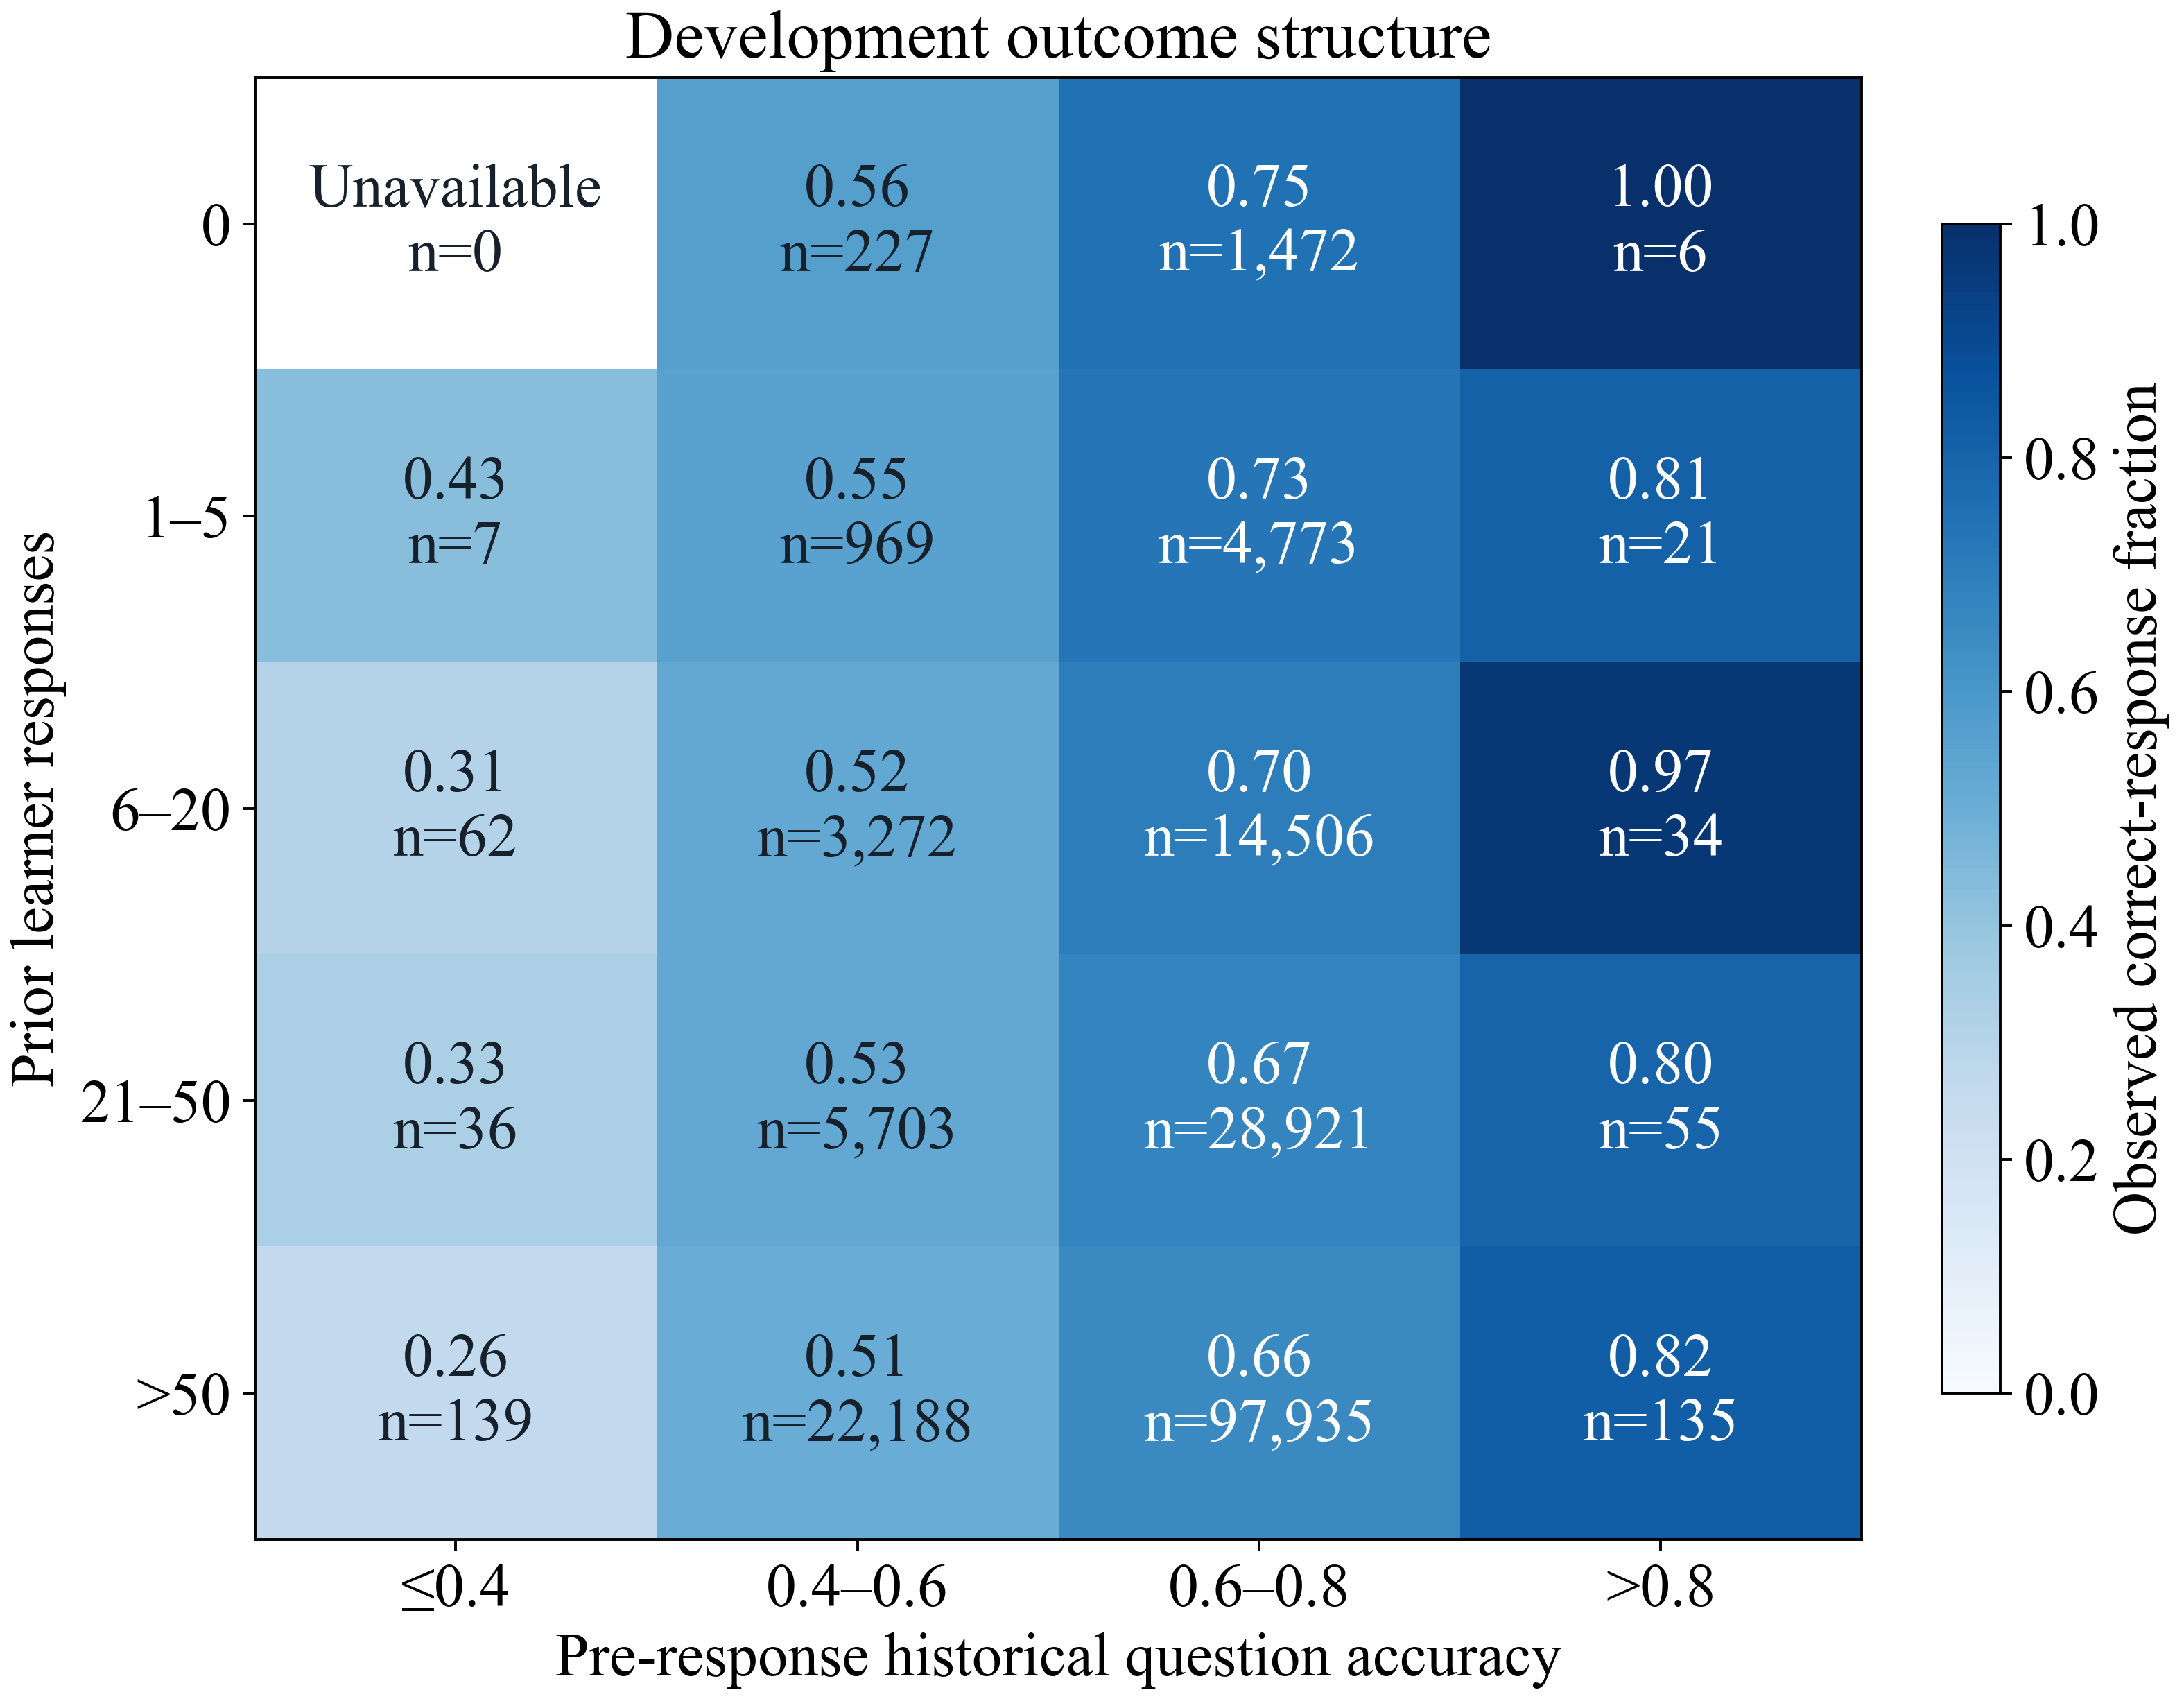

In [37]:
d=development_features.assign(History=pd.cut(development_features.prior_interaction_count,
    [-1,0,5,20,50,np.inf],labels=["0","1–5","6–20","21–50",">50"]),
    Item_rate=pd.cut(development_features.question_historical_accuracy,[-.001,.4,.6,.8,1.001],
    labels=["≤0.4","0.4–0.6","0.6–0.8",">0.8"]))
rates=d.groupby(["History","Item_rate"],observed=False).IsCorrect.mean().unstack()
counts=d.groupby(["History","Item_rate"],observed=False).size().unstack()
fig,ax=plt.subplots(figsize=(9,7),layout="constrained")
im=ax.imshow(rates.to_numpy(),vmin=0,vmax=1,cmap="Blues",aspect="auto")
ax.set_xticks(range(4),rates.columns);ax.set_yticks(range(5),rates.index)
ax.set(xlabel="Pre-response historical question accuracy",ylabel="Prior learner responses")
ax.set_title("Development outcome structure")
for i in range(5):
    for j in range(4):
        value=rates.iloc[i,j];n=int(counts.iloc[i,j])
        label=f"{value:.2f}\nn={n:,}" if n else "Unavailable\nn=0"
        ax.text(j,i,label,ha="center",va="center",fontsize=18,color="white" if value>.6 else "#17212B")
fig.colorbar(im,ax=ax,label="Observed correct-response fraction",shrink=.8)
save_canvas(fig,"development_feature_interaction")

HGB requires no global standardization. Missing values and unseen keys follow the explicit replay and model contracts. Strong dependence between complementary difficulty/accuracy encodings is expected; no variable is removed after inspecting evaluation outcomes. A projection or clustering stage is not part of the claimed mechanism and is not introduced merely to increase the analysis count.

## Interpretation
Calendar separation is enforced globally, not only within learners. Tied events cannot observe one another's outcomes. The singleton EWM update is Eₜ = 0.15yₜ + 0.85Eₜ₋₁, starting at 0.5. The protocol remains completion-ordered: simultaneous presentations and true prediction-time session features cannot be recovered from these files.